# Vehicle Detection with YOLOv8 — Full Pipeline

This notebook trains and compares four YOLOv8 configurations on a vehicle-detection task
(classes: `bus`, `car`, `motorcycle`, `truck`) and then evaluates SAHI (sliced inference)
as a separate inference-time technique on top of the best trained model.

**Plan**

| Part | Experiment             | Model     | Dataset                       | What it answers                              |
|------|------------------------|-----------|-------------------------------|----------------------------------------------|
| 1    | Baseline               | YOLOv8n   | Original (close-up)           | Reference numbers                            |
| 2    | Experiment 1           | YOLOv8m   | Original (close-up)           | Effect of model capacity                     |
| 3    | Experiment 2           | YOLOv8n   | Balanced original + Roboflow  | Effect of data expansion                     |
| 4    | **Final** (best model) | YOLOv8m   | Balanced original + Roboflow  | Best trained configuration                   |
| 5    | Final + SAHI (ablation)| —         | Same weights as Part 4        | Sliced inference vs plain inference          |

Part 5 is not a new model — it reuses the Part-4 weights and only changes how inference
is performed (image is sliced before prediction). For that reason it is reported as a
**separate ablation**, not as a fifth competing model.

For each trained experiment (Parts 1–4) we report overall metrics, per-class metrics,
the confusion matrix, and training curves. Across experiments we then show per-class
grouped charts (4 trained models) and a separate per-class chart for the SAHI ablation
(Final vs Final + SAHI).

## Part 1 — Baseline (YOLOv8n on the original dataset)

### Step 1: Mount Google Drive and check GPU

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Mon May 11 16:59:42 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   57C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Step 2: Install dependencies

In [3]:
!pip install ultralytics -q
import ultralytics
ultralytics.checks()

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 42.9/235.7 GB disk)


### Step 3: Verify dataset on Drive

Before running, upload the dataset to Google Drive with the structure:

```
MyDrive/vehicle_detection/vehicle-detection-project/
├── train/{images,labels}
├── val/{images,labels}
├── test/{images,labels}
└── data.yaml
```

In [4]:
import os

DATASET_PATH = '/content/drive/MyDrive/vehicle_detection/vehicle-detection-project'
DATA_YAML    = os.path.join(DATASET_PATH, 'data.yaml')

assert os.path.exists(DATASET_PATH), f'Dataset folder not found: {DATASET_PATH}'
assert os.path.exists(DATA_YAML),    f'data.yaml not found: {DATA_YAML}'

for split in ['train', 'val', 'test']:
    img_dir = os.path.join(DATASET_PATH, split, 'images')
    lbl_dir = os.path.join(DATASET_PATH, split, 'labels')
    n_img = len(os.listdir(img_dir)) if os.path.exists(img_dir) else 0
    n_lbl = len(os.listdir(lbl_dir)) if os.path.exists(lbl_dir) else 0
    print(f'{split:5s}: {n_img:4d} images, {n_lbl:4d} labels')

train:  714 images,  714 labels
val  :   80 images,   80 labels
test :   80 images,   80 labels


### Step 4: Patch `data.yaml` paths for Colab

In [5]:
import yaml

with open(DATA_YAML, 'r') as f:
    config = yaml.safe_load(f)

config['path'] = DATASET_PATH
COLAB_YAML = '/content/data.yaml'
with open(COLAB_YAML, 'w') as f:
    yaml.dump(config, f, sort_keys=False)

print('Wrote', COLAB_YAML)
print(open(COLAB_YAML).read())

Wrote /content/data.yaml
path: /content/drive/MyDrive/vehicle_detection/vehicle-detection-project
train: train/images
val: val/images
test: test/images
names:
  0: bus
  1: car
  2: motorcycle
  3: truck



### Step 5: Train YOLOv8n (baseline)

In [6]:
from ultralytics import YOLO

RUNS_DIR = '/content/drive/MyDrive/vehicle_detection/vehicle-detection-project/runs'
BASELINE_RUN = 'yolov8n_vehicle'

model_baseline = YOLO('yolov8n.pt')

results_baseline = model_baseline.train(
    data=COLAB_YAML,
    epochs=50,
    batch=16,
    imgsz=640,
    patience=10,
    device=0,
    project=RUNS_DIR,
    name=BASELINE_RUN,
    exist_ok=True,
)

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_vehicle, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, persp

### Step 6: Training curves (losses and metrics)

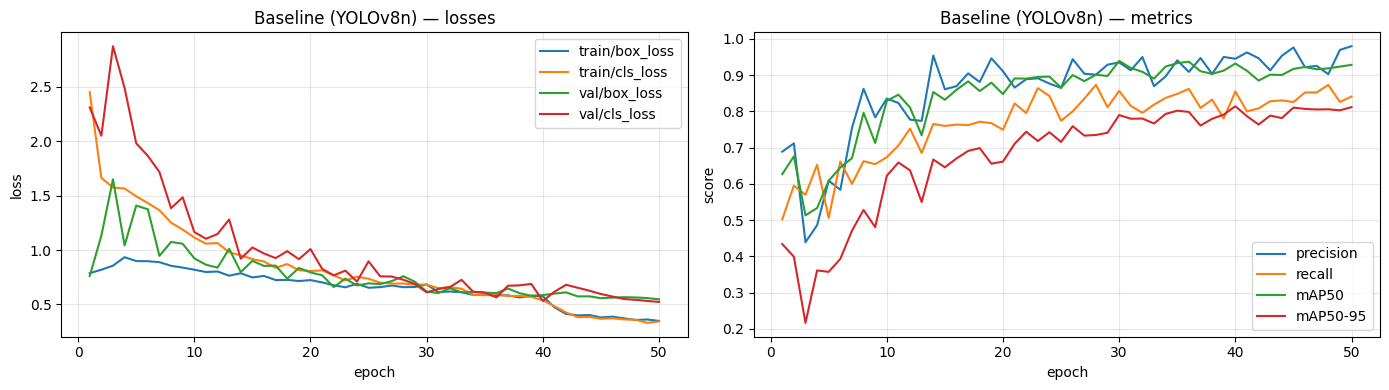

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_training_curves(run_dir, title):
    csv_path = os.path.join(run_dir, 'results.csv')
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    for col in ['train/box_loss', 'train/cls_loss', 'val/box_loss', 'val/cls_loss']:
        if col in df.columns:
            axes[0].plot(df['epoch'], df[col], label=col)
    axes[0].set_xlabel('epoch'); axes[0].set_ylabel('loss')
    axes[0].set_title(f'{title} — losses')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    for col in ['metrics/precision(B)', 'metrics/recall(B)',
                'metrics/mAP50(B)', 'metrics/mAP50-95(B)']:
        if col in df.columns:
            axes[1].plot(df['epoch'], df[col], label=col.replace('metrics/', '').replace('(B)', ''))
    axes[1].set_xlabel('epoch'); axes[1].set_ylabel('score')
    axes[1].set_title(f'{title} — metrics')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout(); plt.show()

BASELINE_RUN_DIR = os.path.join(RUNS_DIR, BASELINE_RUN)
plot_training_curves(BASELINE_RUN_DIR, 'Baseline (YOLOv8n)')

### Step 7: Evaluate baseline on validation set

In [8]:
WEIGHTS_BASELINE = os.path.join(BASELINE_RUN_DIR, 'weights', 'best.pt')
model_baseline = YOLO(WEIGHTS_BASELINE)

val_res = model_baseline.val(data=COLAB_YAML, split='val', verbose=False)
print(f'Val mAP@0.5:      {val_res.box.map50:.4f}')
print(f'Val mAP@0.5:0.95: {val_res.box.map:.4f}')
print(f'Val Precision:    {val_res.box.mp:.4f}')
print(f'Val Recall:       {val_res.box.mr:.4f}')

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.6±0.3 ms, read: 21.4±5.0 MB/s, size: 42.8 KB)
val: Scanning /content/drive/MyDrive/vehicle_detection/vehicle-detection-project/val/labels.cache... 80 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 80/80 22.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.8it/s 2.8s
                   all         80         97      0.945      0.855      0.932      0.814
Speed: 7.0ms preprocess, 5.3ms inference, 0.0ms loss, 3.0ms postprocess per image
Results saved to /content/runs/detect/val
Val mAP@0.5:      0.9320
Val mAP@0.5:0.95: 0.8138
Val Precision:    0.9451
Val Recall:       0.8549


### Step 8: Evaluate baseline on test set

In [9]:
test_res_baseline = model_baseline.val(data=COLAB_YAML, split='test', verbose=False)
print(f'Test mAP@0.5:      {test_res_baseline.box.map50:.4f}')
print(f'Test mAP@0.5:0.95: {test_res_baseline.box.map:.4f}')
print(f'Test Precision:    {test_res_baseline.box.mp:.4f}')
print(f'Test Recall:       {test_res_baseline.box.mr:.4f}')

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.9±0.6 ms, read: 0.1±0.0 MB/s, size: 51.4 KB)
val: Scanning /content/drive/MyDrive/vehicle_detection/vehicle-detection-project/test/labels.cache... 80 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 80/80 19.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 10.5s/it 52.5s
                   all         80         96      0.963      0.898      0.932      0.792
Speed: 3.5ms preprocess, 4.8ms inference, 0.0ms loss, 2.7ms postprocess per image
Results saved to /content/runs/detect/val-2
Test mAP@0.5:      0.9318
Test mAP@0.5:0.95: 0.7916
Test Precision:    0.9635
Test Recall:       0.8979


### Step 9: Per-class metrics (baseline, test set)

The helper below pulls precision, recall, mAP@0.5 and mAP@0.5:0.95 **for each class**
from an Ultralytics validation result. We reuse it for every experiment.

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.6±0.4 ms, read: 31.1±10.9 MB/s, size: 65.8 KB)
val: Scanning /content/drive/MyDrive/vehicle_detection/vehicle-detection-project/test/labels.cache... 80 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 80/80 28.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.4it/s 3.6s
                   all         80         96      0.963      0.898      0.932      0.792
Speed: 4.9ms preprocess, 9.5ms inference, 0.0ms loss, 4.4ms postprocess per image
Results saved to /content/runs/detect/val-3


,class,Precision,Recall,mAP@0.5,mAP@0.5:0.95
0,bus,0.9919,0.8929,0.8950,0.8109
1,car,0.8783,0.7143,0.8421,0.7459
2,motorcycle,0.9836,1.0000,0.9950,0.7277
3,truck,1.0000,0.9846,0.9950,0.8819


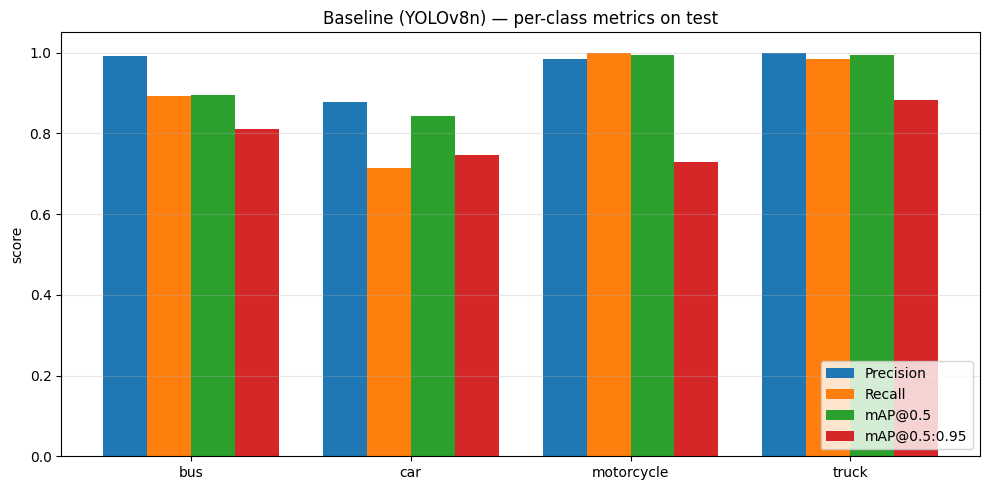

In [10]:
def per_class_metrics(model, data_yaml, split='test'):
    """Return a DataFrame with per-class P / R / mAP@0.5 / mAP@0.5:0.95."""
    res = model.val(data=data_yaml, split=split, verbose=False)
    names = model.names
    if isinstance(names, dict):
        names = [names[i] for i in sorted(names)]

    rows = []
    for i in range(len(names)):
        try:
            p, r, ap50, ap = res.box.class_result(i)
        except Exception:
            p   = float(res.box.p[i])    if hasattr(res.box, 'p')    and i < len(res.box.p)    else float('nan')
            r   = float(res.box.r[i])    if hasattr(res.box, 'r')    and i < len(res.box.r)    else float('nan')
            ap50= float(res.box.ap50[i]) if hasattr(res.box, 'ap50') and i < len(res.box.ap50) else float('nan')
            ap  = float(res.box.ap[i])   if hasattr(res.box, 'ap')   and i < len(res.box.ap)   else float('nan')
        rows.append({
            'class': names[i],
            'Precision': float(p),
            'Recall': float(r),
            'mAP@0.5': float(ap50),
            'mAP@0.5:0.95': float(ap),
        })
    return pd.DataFrame(rows)


def plot_per_class(df, title):
    metrics = ['Precision', 'Recall', 'mAP@0.5', 'mAP@0.5:0.95']
    x = np.arange(len(df))
    width = 0.2
    fig, ax = plt.subplots(figsize=(10, 5))
    for i, m in enumerate(metrics):
        ax.bar(x + (i - 1.5) * width, df[m], width, label=m)
    ax.set_xticks(x); ax.set_xticklabels(df['class'])
    ax.set_ylim(0, 1.05); ax.set_ylabel('score'); ax.set_title(title)
    ax.legend(loc='lower right'); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()


df_baseline_per_class = per_class_metrics(model_baseline, COLAB_YAML, split='test')
display(df_baseline_per_class.round(4))
plot_per_class(df_baseline_per_class, 'Baseline (YOLOv8n) — per-class metrics on test')

### Step 10: Confusion matrix (baseline)

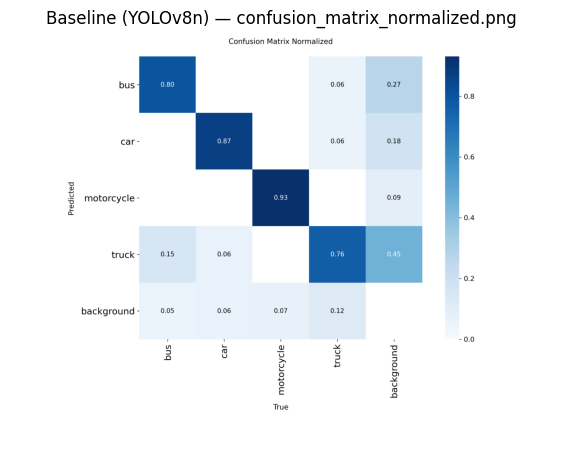

In [11]:
import matplotlib.image as mpimg

def show_confusion_matrix(run_dir, title):
    for name in ['confusion_matrix_normalized.png', 'confusion_matrix.png']:
        p = os.path.join(run_dir, name)
        if os.path.exists(p):
            fig, ax = plt.subplots(figsize=(7, 7))
            ax.imshow(mpimg.imread(p))
            ax.set_title(f'{title} — {name}')
            ax.axis('off')
            plt.show()
            return
    print(f'No confusion matrix found in {run_dir}')

show_confusion_matrix(BASELINE_RUN_DIR, 'Baseline (YOLOv8n)')

### Step 11: Visualise a few baseline predictions

Results saved to /content/drive/MyDrive/vehicle_detection/vehicle-detection-project/runs/predictions_baseline/test_predictions


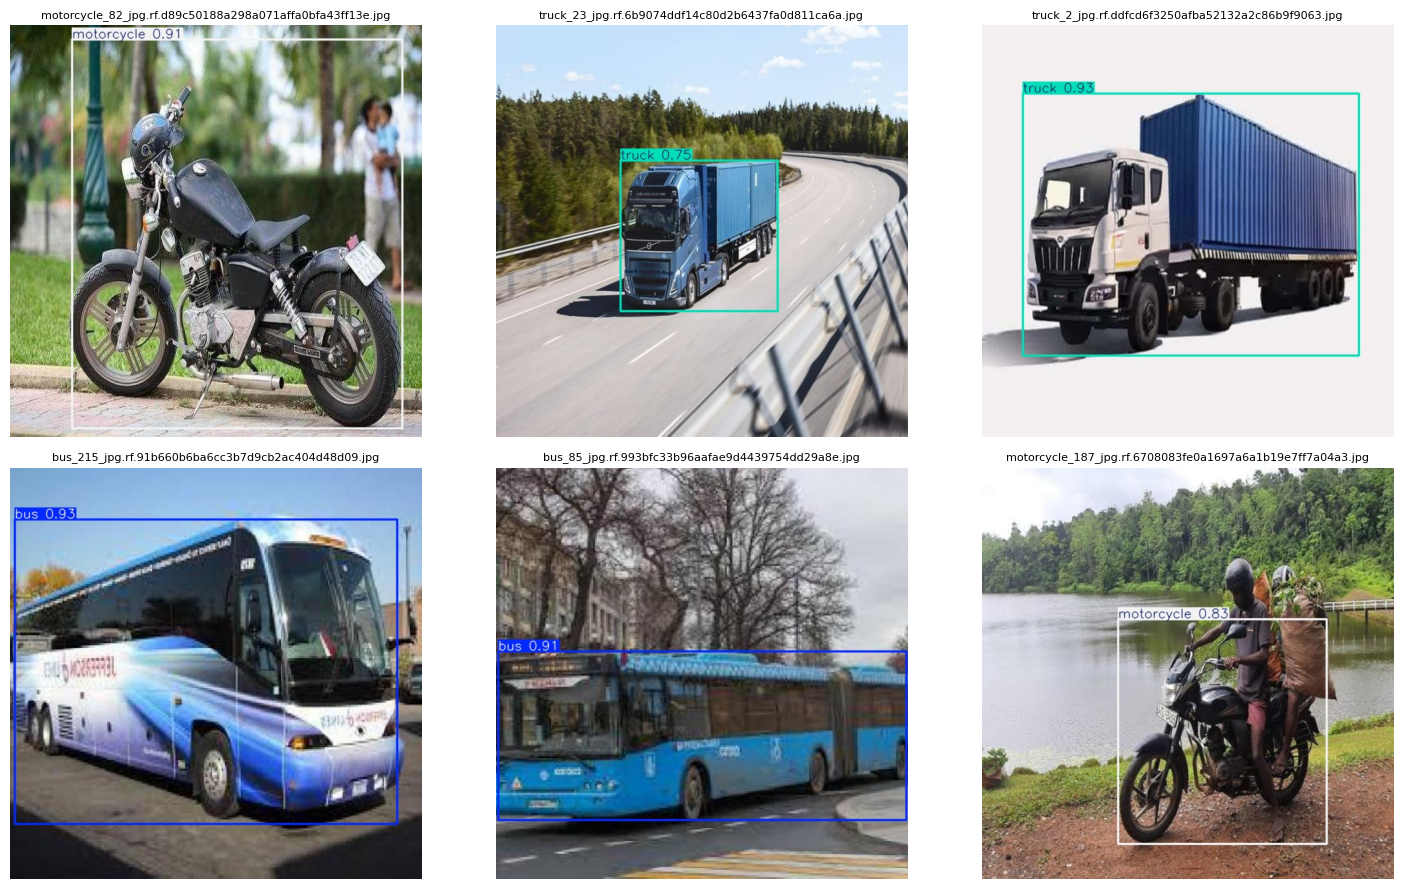

In [13]:
import glob, random
from IPython.display import Image as IPImage, display

TEST_IMAGES = os.path.join(DATASET_PATH, 'test', 'images')
PRED_OUT_DIR = os.path.join(RUNS_DIR, 'predictions_baseline')
os.makedirs(PRED_OUT_DIR, exist_ok=True)

model_baseline.predict(
    source=TEST_IMAGES,
    save=True,
    project=PRED_OUT_DIR,
    name='test_predictions',
    exist_ok=True,
    verbose=False,
)

pred_imgs = sorted(glob.glob(f'{PRED_OUT_DIR}/test_predictions/*.jpg'))
random.seed(44)
samples = random.sample(pred_imgs, min(6, len(pred_imgs)))

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, p in zip(axes.flat, samples):
    ax.imshow(mpimg.imread(p)); ax.axis('off'); ax.set_title(os.path.basename(p), fontsize=8)
plt.tight_layout(); plt.show()

## Part 2 — Experiment 1: YOLOv8m on the original dataset

Same training data and schedule as the baseline; only the backbone capacity changes.

In [14]:
EXP1_RUN = 'yolov8m_exp1'

model_m = YOLO('yolov8m.pt')

results_exp1 = model_m.train(
    data=COLAB_YAML,
    epochs=50,
    batch=16,
    imgsz=640,
    device=0,
    project=RUNS_DIR,
    name=EXP1_RUN,
    exist_ok=True,
)

EXP1_RUN_DIR = os.path.join(RUNS_DIR, EXP1_RUN)
WEIGHTS_EXP1 = os.path.join(EXP1_RUN_DIR, 'weights', 'best.pt')

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8m_exp1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspec

### Comparison: Baseline vs Experiment 1 (overall, original test set)

In [15]:
model_exp1 = YOLO(WEIGHTS_EXP1)
test_res_exp1 = model_exp1.val(data=COLAB_YAML, split='test', verbose=False)

comparison_1 = pd.DataFrame({
    'Metric':              ['mAP@0.5', 'mAP@0.5:0.95', 'Precision', 'Recall'],
    'Baseline (Nano)':     [test_res_baseline.box.map50, test_res_baseline.box.map,
                            test_res_baseline.box.mp,    test_res_baseline.box.mr],
    'Exp 1 (Medium)':      [test_res_exp1.box.map50,     test_res_exp1.box.map,
                            test_res_exp1.box.mp,        test_res_exp1.box.mr],
}).round(4)
display(comparison_1)

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,842,076 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.6±0.3 ms, read: 16.4±8.0 MB/s, size: 56.6 KB)
val: Scanning /content/drive/MyDrive/vehicle_detection/vehicle-detection-project/test/labels.cache... 80 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 80/80 37.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.4it/s 3.6s
                   all         80         96      0.975      0.867      0.939      0.812
Speed: 6.7ms preprocess, 25.1ms inference, 0.1ms loss, 2.5ms postprocess per image
Results saved to /content/runs/detect/val-4


,Metric,Baseline (Nano),Exp 1 (Medium)
0,mAP@0.5,0.9318,0.9393
1,mAP@0.5:0.95,0.7916,0.8122
2,Precision,0.9635,0.9747
3,Recall,0.8979,0.8666


### Per-class metrics — Experiment 1

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.7±0.4 ms, read: 30.9±5.8 MB/s, size: 54.2 KB)
val: Scanning /content/drive/MyDrive/vehicle_detection/vehicle-detection-project/test/labels.cache... 80 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 80/80 28.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.2it/s 4.3s
                   all         80         96      0.975      0.867      0.939      0.812
Speed: 11.0ms preprocess, 25.7ms inference, 0.0ms loss, 2.8ms postprocess per image
Results saved to /content/runs/detect/val-5


,class,Precision,Recall,mAP@0.5,mAP@0.5:0.95
0,bus,1.0000,0.8322,0.9120,0.8576
1,car,0.9278,0.7143,0.8584,0.7936
2,motorcycle,0.9864,1.0000,0.9950,0.7085
3,truck,0.9847,0.9200,0.9919,0.8890


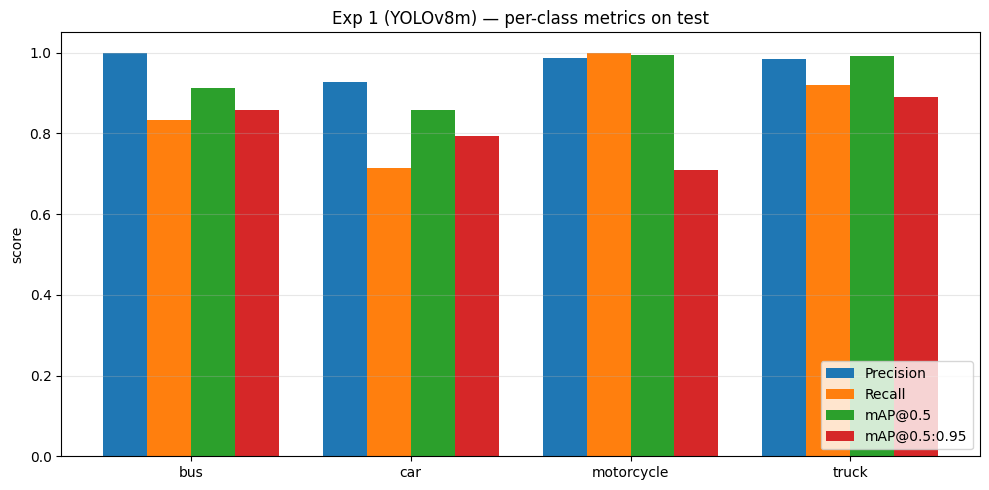

In [16]:
df_exp1_per_class = per_class_metrics(model_exp1, COLAB_YAML, split='test')
display(df_exp1_per_class.round(4))
plot_per_class(df_exp1_per_class, 'Exp 1 (YOLOv8m) — per-class metrics on test')

### Training curves and confusion matrix — Experiment 1

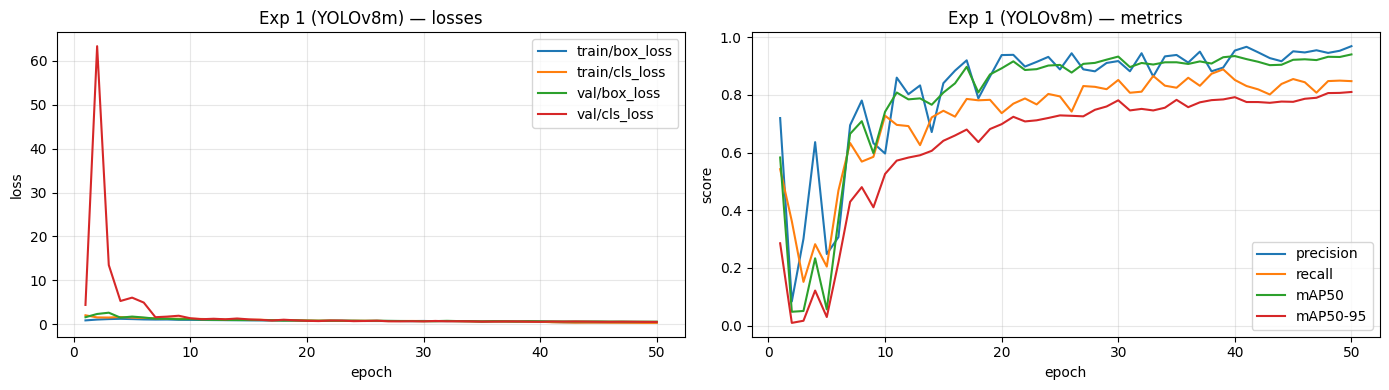

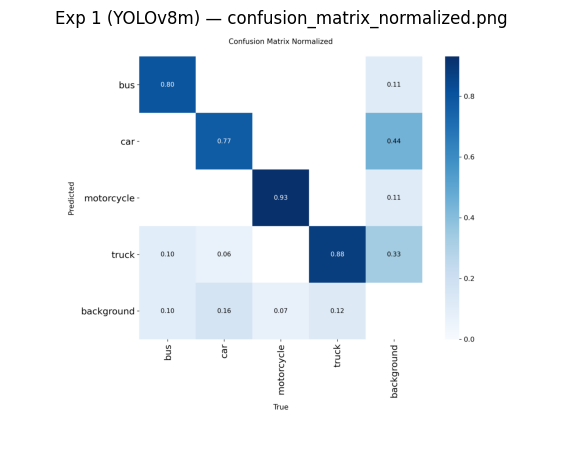

In [17]:
plot_training_curves(EXP1_RUN_DIR, 'Exp 1 (YOLOv8m)')
show_confusion_matrix(EXP1_RUN_DIR, 'Exp 1 (YOLOv8m)')

## Part 3 — Experiment 2: Dataset Expansion

We download an additional traffic-camera dataset from Roboflow, harmonise its class names
with ours, and train YOLOv8n on a **balanced** merged dataset.

The class mapping is built **dynamically** from the Roboflow `data.yaml` (matching by name),
so a Roboflow version change does not silently corrupt labels.

In [18]:
!pip install roboflow -q

import shutil, random
from roboflow import Roboflow

rf = Roboflow(api_key='Wfetji1eTEiH7q2T4F1I')
project = rf.workspace('traffic-camera').project('vehicles-22g3b')
version = project.version(7)
new_ds = version.download('yolov8')

with open(os.path.join(new_ds.location, 'data.yaml')) as f:
    rf_cfg = yaml.safe_load(f)

rf_names_raw = rf_cfg['names']
if isinstance(rf_names_raw, list):
    rf_names = {i: n for i, n in enumerate(rf_names_raw)}
else:
    rf_names = {int(k): v for k, v in rf_names_raw.items()}

target_classes = {'bus': 0, 'car': 1, 'motorcycle': 2, 'truck': 3}
class_map = {rf_id: target_classes[name]
             for rf_id, name in rf_names.items()
             if name in target_classes}

print('Roboflow classes:        ', rf_names)
print('Target classes:          ', target_classes)
print('Class mapping (rf -> us):', class_map)
skipped = [n for i, n in rf_names.items() if i not in class_map]
if skipped:
    print('Skipped (not in targets):', skipped)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 89.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 109.6 MB/s eta 0:00:00
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Vehicles-7 in yolov8:: 100%|██████████| 1740/1740 [00:01<00:00, 1558.58it/s]

Roboflow classes:         {0: 'bus', 1: 'car', 2: 'motorcycle', 3: 'truck', 4: 'xbicycle'}
Target classes:           {'bus': 0, 'car': 1, 'motorcycle': 2, 'truck': 3}
Class mapping (rf -> us): {0: 0, 1: 1, 2: 2, 3: 3}
Skipped (not in targets): ['xbicycle']


### Build a *balanced* expanded dataset

The Roboflow pool is much larger than our baseline, so if we just concatenate the two
the trained model is dominated by distant traffic-camera shots. To keep close-up and
distant data on equal footing, we sample Roboflow so that **every split has the same
number of baseline (`bl_`) and Roboflow (`rf_`) images**.

Roboflow images whose labels are entirely outside our 4 target classes (e.g. only
`ambulance`) are skipped — we only keep images that still have at least one valid
annotation after the class remap.

This balanced expanded dataset is used for **both Experiment 2 and the Final model**.

In [19]:
EXPANDED_DATASET_DIR = '/content/expanded_dataset'
for split in ['train', 'val', 'test']:
    os.makedirs(os.path.join(EXPANDED_DATASET_DIR, split, 'images'), exist_ok=True)
    os.makedirs(os.path.join(EXPANDED_DATASET_DIR, split, 'labels'), exist_ok=True)

IMG_EXTS = ('.jpg', '.jpeg', '.png')


# 1) How many baseline images do we have in each split? That is our target Roboflow count.
def count_baseline(split):
    img_dir = os.path.join(DATASET_PATH, split, 'images')
    return sum(1 for f in os.listdir(img_dir) if f.lower().endswith(IMG_EXTS))


target_counts = {split: count_baseline(split) for split in ['train', 'val', 'test']}
print('Target counts per split (baseline = Roboflow):', target_counts)


# 2) Pool every Roboflow image that still has >= 1 mapped label.
def collect_roboflow_pool():
    pool = []
    for split in ['train', 'val', 'test']:
        img_dir = os.path.join(new_ds.location, split, 'images')
        lbl_dir = os.path.join(new_ds.location, split, 'labels')
        if not os.path.exists(img_dir):
            continue
        for img_name in os.listdir(img_dir):
            if not img_name.lower().endswith(IMG_EXTS):
                continue
            lbl_name = os.path.splitext(img_name)[0] + '.txt'
            lbl_path = os.path.join(lbl_dir, lbl_name)
            remapped = []
            if os.path.exists(lbl_path):
                with open(lbl_path) as f:
                    for line in f:
                        parts = line.split()
                        if not parts:
                            continue
                        cls_id = int(parts[0])
                        if cls_id in class_map:
                            parts[0] = str(class_map[cls_id])
                            remapped.append(' '.join(parts))
            if remapped:
                pool.append((os.path.join(img_dir, img_name), remapped))
    return pool


rf_pool = collect_roboflow_pool()
print(f'Eligible Roboflow images: {len(rf_pool)}')

random.seed(42)
random.shuffle(rf_pool)

selected = {}
cursor = 0
for split in ['train', 'val', 'test']:
    want = target_counts[split]
    take = rf_pool[cursor:cursor + want]
    selected[split] = take
    cursor += len(take)
    if len(take) < want:
        print(f'  WARNING: split={split} wanted {want} Roboflow imgs, got {len(take)}')


# 3) Copy baseline as-is (bl_ prefix). Write Roboflow images + remapped labels (rf_ prefix).
def copy_baseline_split(split):
    img_dir = os.path.join(DATASET_PATH, split, 'images')
    lbl_dir = os.path.join(DATASET_PATH, split, 'labels')
    dst_img = os.path.join(EXPANDED_DATASET_DIR, split, 'images')
    dst_lbl = os.path.join(EXPANDED_DATASET_DIR, split, 'labels')
    n = 0
    for img_name in os.listdir(img_dir):
        if not img_name.lower().endswith(IMG_EXTS):
            continue
        lbl_name = os.path.splitext(img_name)[0] + '.txt'
        shutil.copy(os.path.join(img_dir, img_name),
                    os.path.join(dst_img, f'bl_{split}_{img_name}'))
        src_lbl = os.path.join(lbl_dir, lbl_name)
        if os.path.exists(src_lbl):
            shutil.copy(src_lbl, os.path.join(dst_lbl, f'bl_{split}_{lbl_name}'))
        n += 1
    return n


def write_roboflow_split(split, items):
    dst_img = os.path.join(EXPANDED_DATASET_DIR, split, 'images')
    dst_lbl = os.path.join(EXPANDED_DATASET_DIR, split, 'labels')
    for img_path, lines in items:
        img_name = os.path.basename(img_path)
        lbl_name = os.path.splitext(img_name)[0] + '.txt'
        shutil.copy(img_path, os.path.join(dst_img, f'rf_{split}_{img_name}'))
        with open(os.path.join(dst_lbl, f'rf_{split}_{lbl_name}'), 'w') as f:
            f.write('\n'.join(lines) + '\n')


print('\nFinal split counts:')
for split in ['train', 'val', 'test']:
    n_bl = copy_baseline_split(split)
    write_roboflow_split(split, selected[split])
    n_rf = len(selected[split])
    print(f'  {split:5s}: {n_bl} baseline + {n_rf} roboflow = {n_bl + n_rf}')


expanded_yaml = {
    'path':  EXPANDED_DATASET_DIR,
    'train': 'train/images',
    'val':   'val/images',
    'test':  'test/images',
    'names': {0: 'bus', 1: 'car', 2: 'motorcycle', 3: 'truck'},
}
EXPANDED_YAML_PATH = '/content/expanded_data.yaml'
with open(EXPANDED_YAML_PATH, 'w') as f:
    yaml.dump(expanded_yaml, f, sort_keys=False)

print('\nWrote', EXPANDED_YAML_PATH)

Target counts per split (baseline = Roboflow): {'train': 714, 'val': 80, 'test': 80}
Eligible Roboflow images: 854

Final split counts:
  train: 714 baseline + 714 roboflow = 1428
  val  : 80 baseline + 80 roboflow = 160
  test : 80 baseline + 60 roboflow = 140

Wrote /content/expanded_data.yaml


### Train YOLOv8n on the expanded dataset

In [20]:
EXP2_RUN = 'yolov8n_expanded'

model_n_expanded = YOLO('yolov8n.pt')
results_exp2 = model_n_expanded.train(
    data=EXPANDED_YAML_PATH,
    epochs=50,
    batch=16,
    imgsz=640,
    device=0,
    project=RUNS_DIR,
    name=EXP2_RUN,
    exist_ok=True,
)

EXP2_RUN_DIR = os.path.join(RUNS_DIR, EXP2_RUN)
WEIGHTS_EXP2 = os.path.join(EXP2_RUN_DIR, 'weights', 'best.pt')

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/expanded_data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_expanded, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience

### Comparison: Baseline vs Experiment 2 (overall, expanded test set)

We re-evaluate **both** models on the same expanded test set so the comparison is fair.

In [21]:
model_exp2 = YOLO(WEIGHTS_EXP2)

baseline_on_expanded = model_baseline.val(data=EXPANDED_YAML_PATH, split='test', verbose=False)
exp2_on_expanded     = model_exp2.val   (data=EXPANDED_YAML_PATH, split='test', verbose=False)

comparison_2 = pd.DataFrame({
    'Metric':                  ['mAP@0.5', 'mAP@0.5:0.95', 'Precision', 'Recall'],
    'Baseline (Nano)':         [baseline_on_expanded.box.map50, baseline_on_expanded.box.map,
                                baseline_on_expanded.box.mp,    baseline_on_expanded.box.mr],
    'Exp 2 (Nano + Roboflow)': [exp2_on_expanded.box.map50,     exp2_on_expanded.box.map,
                                exp2_on_expanded.box.mp,        exp2_on_expanded.box.mr],
}).round(4)
display(comparison_2)

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 44.7±47.5 MB/s, size: 180.8 KB)
val: Scanning /content/expanded_dataset/test/labels... 140 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 140/140 561.0it/s 0.2s
val: New cache created: /content/expanded_dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 1.2it/s 7.7s
                   all        140        688      0.791      0.414      0.453      0.366
Speed: 10.5ms preprocess, 12.3ms inference, 0.0ms loss, 7.4ms postprocess per image
Results saved to /content/runs/detect/val-6
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2025.8±1053.7 MB/s, size: 171.1 KB)
val: Scanning /content/expanded_dataset/te

,Metric,Baseline (Nano),Exp 2 (Nano + Roboflow)
0,mAP@0.5,0.4535,0.9363
1,mAP@0.5:0.95,0.3663,0.7479
2,Precision,0.7905,0.9461
3,Recall,0.4138,0.8625


### Per-class metrics — Experiment 2

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1954.9±1113.8 MB/s, size: 208.7 KB)
val: Scanning /content/expanded_dataset/test/labels.cache... 140 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 140/140 39.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 2.0it/s 4.6s
                   all        140        688      0.946      0.863      0.936      0.748
Speed: 2.6ms preprocess, 4.7ms inference, 0.0ms loss, 3.0ms postprocess per image
Results saved to /content/runs/detect/val-8


,class,Precision,Recall,mAP@0.5,mAP@0.5:0.95
0,bus,0.9520,0.8750,0.9277,0.7871
1,car,0.9697,0.7996,0.9125,0.7155
2,motorcycle,0.9369,0.8168,0.9201,0.6206
3,truck,0.9257,0.9587,0.9850,0.8686


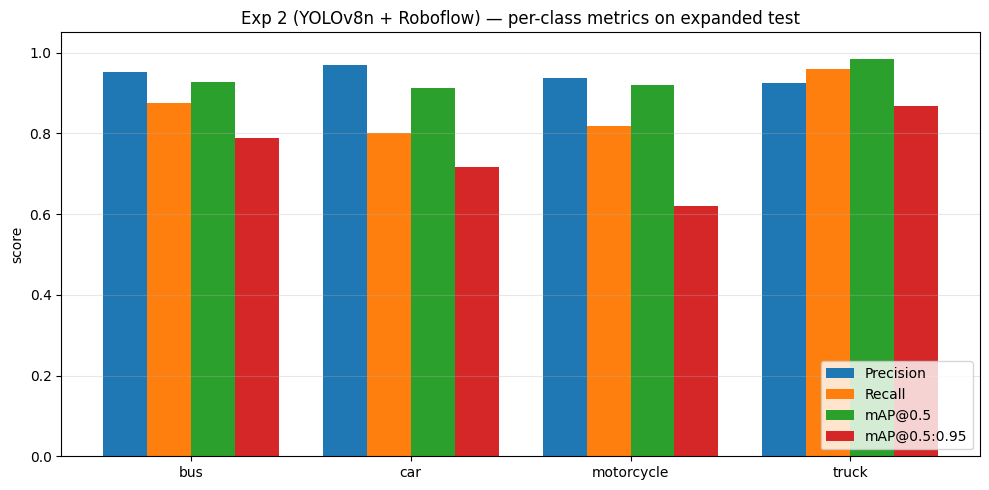

In [22]:
df_exp2_per_class = per_class_metrics(model_exp2, EXPANDED_YAML_PATH, split='test')
display(df_exp2_per_class.round(4))
plot_per_class(df_exp2_per_class, 'Exp 2 (YOLOv8n + Roboflow) — per-class metrics on expanded test')

### Training curves and confusion matrix — Experiment 2

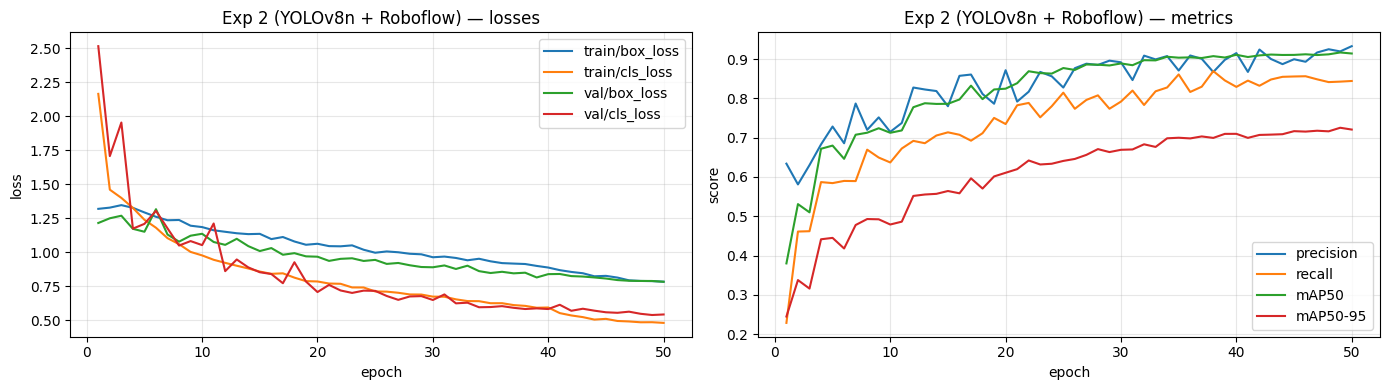

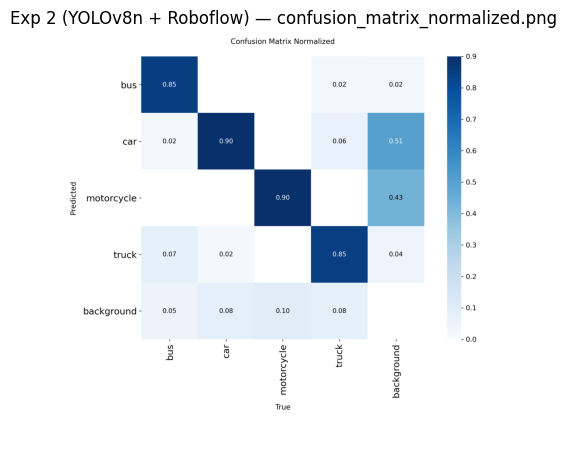

In [23]:
plot_training_curves(EXP2_RUN_DIR, 'Exp 2 (YOLOv8n + Roboflow)')
show_confusion_matrix(EXP2_RUN_DIR, 'Exp 2 (YOLOv8n + Roboflow)')

## Part 4 — Final model: YOLOv8m on the balanced expanded dataset

This combines the two improvements explored separately in Parts 2 and 3 — larger backbone
**and** broader training data. Empirically this is the best trained configuration we get,
and we treat it as our **recommended model**.

SAHI (sliced inference) is **not** trained here; it is a separate inference-time
technique evaluated in Part 5 on these same weights.

### 4.1 — Train YOLOv8m on the expanded dataset

In [ ]:
FINAL_RUN = 'yolov8m_final'

model_m_expanded = YOLO('yolov8m.pt')
results_final = model_m_expanded.train(
    data=EXPANDED_YAML_PATH,
    epochs=50,
    batch=16,
    imgsz=640,
    device=0,
    project=RUNS_DIR,
    name=FINAL_RUN,
    exist_ok=True,
)

FINAL_RUN_DIR = os.path.join(RUNS_DIR, FINAL_RUN)
WEIGHTS_FINAL = os.path.join(FINAL_RUN_DIR, 'weights', 'best.pt')

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/expanded_data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8m_final, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10

### 4.2 — Re-evaluate all four trained models on the expanded test set

This is the main comparison of trained configurations. SAHI is *not* included here —
it is evaluated separately in Part 5.

In [2]:
models_info = {
    'Baseline (Nano)':       WEIGHTS_BASELINE,
    'Exp 1 (Medium)':        WEIGHTS_EXP1,
    'Exp 2 (Nano+Extra)':    WEIGHTS_EXP2,
    'Final (Medium+Extra)':  WEIGHTS_FINAL,
}

per_class_by_model = {}
rows = []
for name, weights in models_info.items():
    print(f'Evaluating {name} ...')
    m = YOLO(weights)
    res = m.val(data=EXPANDED_YAML_PATH, split='test', verbose=False)
    rows.append({
        'Model':         name,
        'mAP@0.5':       round(res.box.map50, 4),
        'mAP@0.5:0.95':  round(res.box.map,   4),
        'Precision':     round(res.box.mp,    4),
        'Recall':        round(res.box.mr,    4),
    })
    per_class_by_model[name] = per_class_metrics(m, EXPANDED_YAML_PATH, split='test')

df_trained = pd.DataFrame(rows)
print('\n=== Trained-model comparison on the balanced expanded test set ===')
display(df_trained)
df_trained.to_csv(os.path.join(RUNS_DIR, 'trained_models_comparison.csv'), index=False)

NameError: name 'WEIGHTS_BASELINE' is not defined

### 4.3 — Per-class metrics — Final model

In [ ]:
df_final_per_class = per_class_by_model['Final (Medium+Extra)']
display(df_final_per_class.round(4))
plot_per_class(df_final_per_class, 'Final (YOLOv8m + Roboflow) — per-class metrics on expanded test')

### 4.4 — Training curves and confusion matrix — Final model

In [ ]:
plot_training_curves(FINAL_RUN_DIR, 'Final (YOLOv8m + Roboflow)')
show_confusion_matrix(FINAL_RUN_DIR, 'Final (YOLOv8m + Roboflow)')

### 4.5 — Per-class comparison across the four trained models

Same balanced expanded test set, four trained configurations.

In [ ]:
def plot_grouped_per_class(per_class_dfs, metric, title, ylim=(0, 1.05)):
    classes = list(per_class_dfs.values())[0]['class'].tolist()
    x = np.arange(len(classes))
    n = len(per_class_dfs)
    width = 0.8 / n
    fig, ax = plt.subplots(figsize=(12, 5))
    for i, (name, df) in enumerate(per_class_dfs.items()):
        if metric not in df.columns:
            continue
        offset = (i - (n - 1) / 2) * width
        ax.bar(x + offset, df[metric].astype(float), width, label=name)
    ax.set_xticks(x); ax.set_xticklabels(classes)
    ax.set_ylim(*ylim); ax.set_ylabel(metric); ax.set_title(title)
    ax.legend(loc='lower right', fontsize=8); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()


for metric in ['mAP@0.5', 'mAP@0.5:0.95', 'Precision', 'Recall']:
    plot_grouped_per_class(
        per_class_by_model,
        metric,
        f'Per-class {metric} — 4 trained models (expanded test set)',
    )

## Part 5 — SAHI ablation (separate inference-time technique)

SAHI does not train a new model. It takes the **Final weights from Part 4** and changes
how inference is performed: each test image is split into overlapping tiles, predictions
are run per tile, and the results are merged. This typically helps on small / distant
objects at the cost of inference time.

To keep the comparison clean we report SAHI as an **ablation against the same Final
weights** — Final without SAHI vs Final with SAHI — instead of mixing it into the
4-model trained comparison above.

### 5.1 — Install SAHI and load the Final weights as a SAHI detection model

In [ ]:
!pip install sahi -q

from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction
from PIL import Image

detection_model = AutoDetectionModel.from_pretrained(
    model_type='ultralytics',
    model_path=WEIGHTS_FINAL,
    confidence_threshold=0.45,
    device='cuda:0',
)


def compute_iou(b1, b2):
    x1, y1 = max(b1[0], b2[0]), max(b1[1], b2[1])
    x2, y2 = min(b1[2], b2[2]), min(b1[3], b2[3])
    inter  = max(0, x2 - x1) * max(0, y2 - y1)
    union  = (b1[2]-b1[0])*(b1[3]-b1[1]) + (b2[2]-b2[0])*(b2[3]-b2[1]) - inter
    return inter / union if union > 0 else 0


def yolo_to_xyxy(cx, cy, w, h, W, H):
    return [(cx - w/2)*W, (cy - h/2)*H, (cx + w/2)*W, (cy + h/2)*H]

### 5.2 — SAHI per-class metrics on the expanded test set

Class-aware matching: a prediction counts as a TP only if the predicted class matches
the ground-truth class **and** IoU ≥ 0.5. SAHI returns single-IoU predictions, so we
report Precision / Recall / F1 per class (no COCO-style mAP).

In [ ]:
CLASS_NAMES = ['bus', 'car', 'motorcycle', 'truck']
NC = len(CLASS_NAMES)

test_images = sorted(
    glob.glob(os.path.join(EXPANDED_DATASET_DIR, 'test', 'images', '*.jpg')) +
    glob.glob(os.path.join(EXPANDED_DATASET_DIR, 'test', 'images', '*.png'))
)
label_dir = os.path.join(EXPANDED_DATASET_DIR, 'test', 'labels')

tp = [0]*NC; fp = [0]*NC; fn = [0]*NC

for img_path in test_images:
    img = Image.open(img_path); W, H = img.size

    res = get_sliced_prediction(
        img_path, detection_model,
        slice_height=640, slice_width=640,
        overlap_height_ratio=0.1, overlap_width_ratio=0.1,
    )

    lbl_path = os.path.join(label_dir, os.path.splitext(os.path.basename(img_path))[0] + '.txt')
    gts = []
    if os.path.exists(lbl_path):
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    c = int(parts[0])
                    cx, cy, w, h = map(float, parts[1:])
                    gts.append((c, yolo_to_xyxy(cx, cy, w, h, W, H)))

    preds = sorted(
        [(op.category.id, [op.bbox.minx, op.bbox.miny, op.bbox.maxx, op.bbox.maxy], op.score.value)
         for op in res.object_prediction_list],
        key=lambda x: -x[2],
    )

    matched = set()
    for c_p, bb_p, _ in preds:
        best_iou, best_idx = 0, -1
        for i, (c_g, bb_g) in enumerate(gts):
            if i in matched or c_g != c_p:
                continue
            iou = compute_iou(bb_p, bb_g)
            if iou > best_iou:
                best_iou, best_idx = iou, i
        if best_iou >= 0.5:
            tp[c_p] += 1; matched.add(best_idx)
        else:
            fp[c_p] += 1

    for i, (c_g, _) in enumerate(gts):
        if i not in matched:
            fn[c_g] += 1

sahi_rows = []
for i, name in enumerate(CLASS_NAMES):
    p = tp[i] / (tp[i] + fp[i]) if (tp[i] + fp[i]) > 0 else 0.0
    r = tp[i] / (tp[i] + fn[i]) if (tp[i] + fn[i]) > 0 else 0.0
    sahi_rows.append({
        'class': name,
        'Precision': p, 'Recall': r,
        'F1': 2 * p * r / (p + r + 1e-9),
        'TP': tp[i], 'FP': fp[i], 'FN': fn[i],
    })
df_sahi_per_class = pd.DataFrame(sahi_rows)
display(df_sahi_per_class.round(4))

TP, FP, FN = sum(tp), sum(fp), sum(fn)
sahi_precision = TP / (TP + FP) if (TP + FP) > 0 else 0
sahi_recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
sahi_f1        = 2 * sahi_precision * sahi_recall / (sahi_precision + sahi_recall + 1e-9)
print(f'\nSAHI overall: P={sahi_precision:.4f}  R={sahi_recall:.4f}  F1={sahi_f1:.4f}')

### 5.3 — Ablation table: Final vs Final + SAHI

Same weights, two inference modes.

In [ ]:
final_row = df_trained[df_trained['Model'] == 'Final (Medium+Extra)'].iloc[0]

ablation = pd.DataFrame([
    {
        'Inference':     'Final (plain)',
        'mAP@0.5':       final_row['mAP@0.5'],
        'mAP@0.5:0.95':  final_row['mAP@0.5:0.95'],
        'Precision':     final_row['Precision'],
        'Recall':        final_row['Recall'],
    },
    {
        'Inference':     'Final + SAHI',
        'mAP@0.5':       '—',
        'mAP@0.5:0.95':  '—',
        'Precision':     round(sahi_precision, 4),
        'Recall':        round(sahi_recall,    4),
    },
])


def _f1(p, r):
    try:
        return round(2 * float(p) * float(r) / (float(p) + float(r) + 1e-9), 4)
    except Exception:
        return float('nan')


ablation['F1'] = ablation.apply(lambda row: _f1(row['Precision'], row['Recall']), axis=1)
display(ablation)
ablation.to_csv(os.path.join(RUNS_DIR, 'sahi_ablation.csv'), index=False)

### 5.4 — Per-class ablation: Final vs Final + SAHI

Same Precision / Recall metric per class, two inference modes.

In [ ]:
# Per-class Final (plain) vs Final+SAHI on the same expanded test set.
final_per_class = per_class_by_model['Final (Medium+Extra)'][['class', 'Precision', 'Recall']]
sahi_per_class  = df_sahi_per_class[['class', 'Precision', 'Recall']]

ablation_per_class = {
    'Final (plain)': final_per_class,
    'Final + SAHI':  sahi_per_class,
}

plot_grouped_per_class(ablation_per_class, 'Precision',
    'Per-class Precision — Final vs Final + SAHI')
plot_grouped_per_class(ablation_per_class, 'Recall',
    'Per-class Recall — Final vs Final + SAHI')

## Detection examples: Baseline vs Final

Three random test images, predicted by the baseline (left) and the final model (right).

In [ ]:
sample_imgs = random.Random(7).sample(test_images, min(3, len(test_images)))

model_b = YOLO(WEIGHTS_BASELINE)
model_f = YOLO(WEIGHTS_FINAL)

fig, axes = plt.subplots(len(sample_imgs), 2, figsize=(14, 5 * len(sample_imgs)))
if len(sample_imgs) == 1:
    axes = np.array([axes])

for i, img_path in enumerate(sample_imgs):
    r_b = model_b.predict(img_path, verbose=False, conf=0.25)[0]
    r_f = model_f.predict(img_path, verbose=False, conf=0.25)[0]

    axes[i, 0].imshow(r_b.plot()[..., ::-1])
    axes[i, 0].set_title(f'Baseline (Nano) — {os.path.basename(img_path)}', fontsize=10)
    axes[i, 0].axis('off')

    axes[i, 1].imshow(r_f.plot()[..., ::-1])
    axes[i, 1].set_title('Final (Medium + Roboflow)', fontsize=10)
    axes[i, 1].axis('off')

plt.tight_layout(); plt.show()

## Summary

**Recommended model:** `Final (YOLOv8m on the balanced expanded dataset)` — Part 4.
On the balanced expanded test set it beats the three other trained configurations on
overall and per-class mAP/Precision/Recall. This is the model you would deploy.

**SAHI (Part 5)** is an inference-time technique tested on the same Final weights. It
typically trades precision for recall on small/distant objects. It is reported as a
separate ablation row, not as a fifth model.

Artifacts saved to Drive:

- `runs/yolov8n_vehicle/`              — baseline weights + training logs
- `runs/yolov8m_exp1/`                 — Experiment 1 (medium, original dataset)
- `runs/yolov8n_expanded/`             — Experiment 2 (nano, balanced expanded)
- `runs/yolov8m_final/`                — **Final model** (medium, balanced expanded) — recommended
- `runs/trained_models_comparison.csv` — overall metrics, 4 trained models
- `runs/sahi_ablation.csv`             — Final vs Final + SAHI ablation